# 1. Basic 

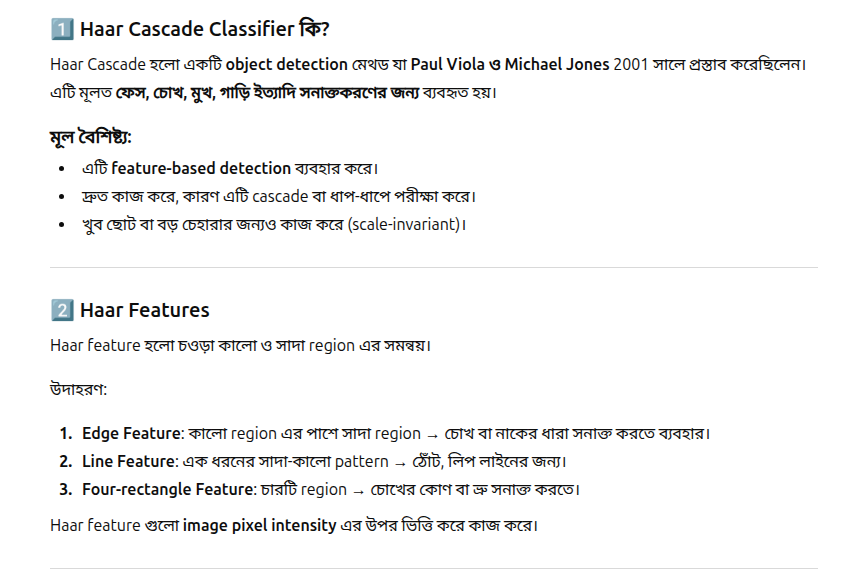

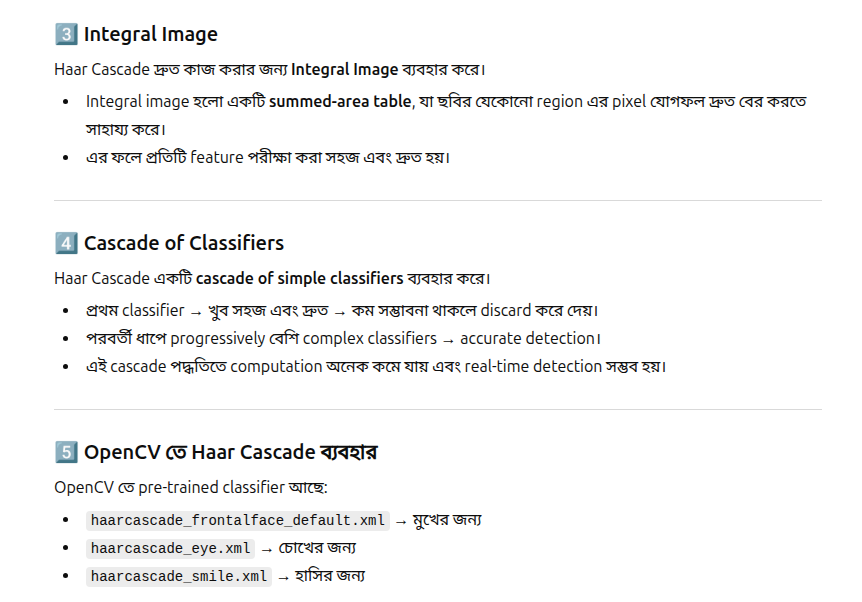

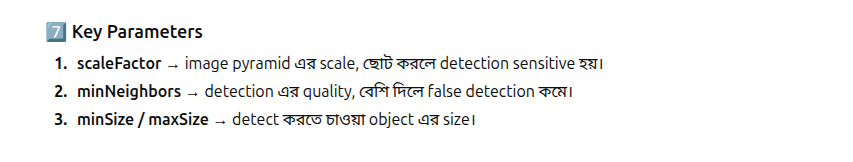

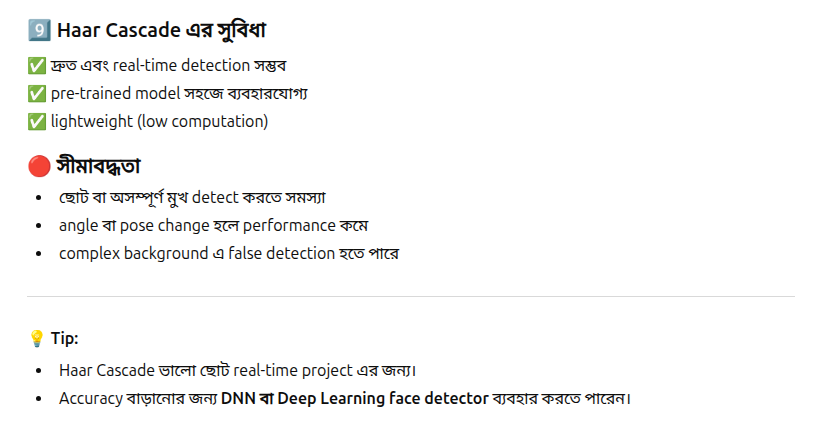

## 1. Individual Image Detection

In [2]:
import cv2

# Haar Cascade লোড
face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')

# ইমেজ লোড
img = cv2.imread('../dataset/test/bellingham.jpg')
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# মুখ সনাক্তকরণ
faces = face_cascade.detectMultiScale(gray, scaleFactor=1.1, minNeighbors=5)

# detected faces draw
for (x, y, w, h) in faces:
    cv2.rectangle(img, (x, y), (x+w, y+h), (255, 0, 0), 2)

cv2.imshow('Face Detection - Image', img)
cv2.waitKey(0)
cv2.destroyAllWindows()

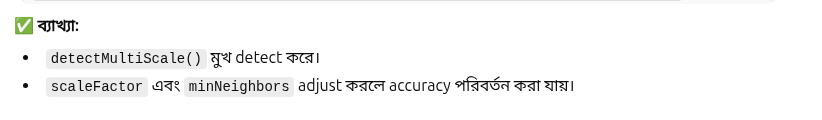

## 2. Video File Detection

In [3]:
import cv2

# Haar Cascade লোড
face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')

# ভিডিও লোড
cap = cv2.VideoCapture('../dataset/vid/s.mp4')

while True:
    ret, frame = cap.read()
    if not ret:
        break

    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    faces = face_cascade.detectMultiScale(gray, 1.1, 5)

    for (x, y, w, h) in faces:
        cv2.rectangle(frame, (x, y), (x+w, y+h), (255, 0, 0), 2)

    cv2.imshow('Face Detection - Video', frame)

    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

cap.release()
cv2.destroyAllWindows()

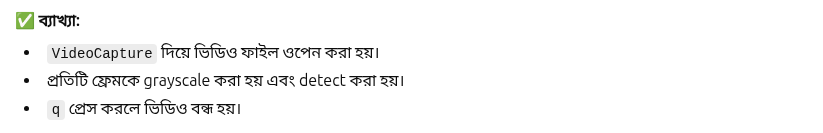

## 3. Webcam Detection (Real-Time)

In [4]:
import cv2

# Haar Cascade লোড
face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')

# Webcam Capture
cap = cv2.VideoCapture(0)

while True:
    ret, frame = cap.read()
    if not ret:
        break

    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    faces = face_cascade.detectMultiScale(gray, 1.1, 5)

    for (x, y, w, h) in faces:
        cv2.rectangle(frame, (x, y), (x+w, y+h), (0, 255, 0), 2)

    cv2.imshow('Face Detection - Webcam', frame)

    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

cap.release()
cv2.destroyAllWindows()

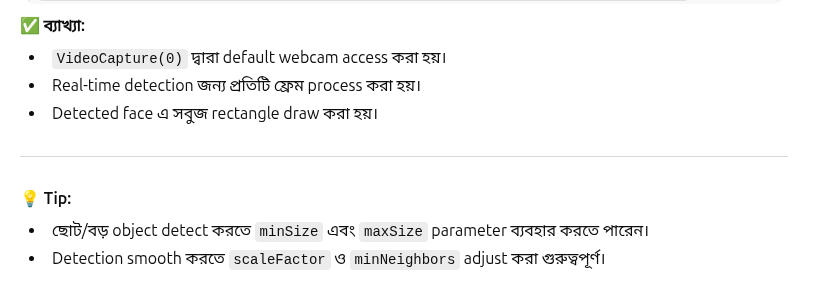

# 2. Tips

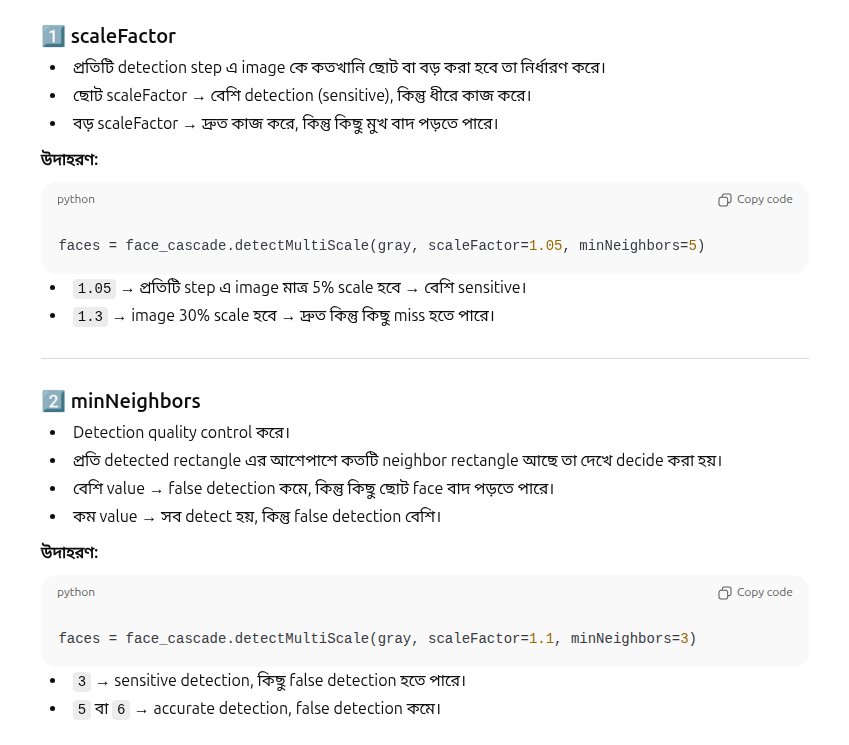

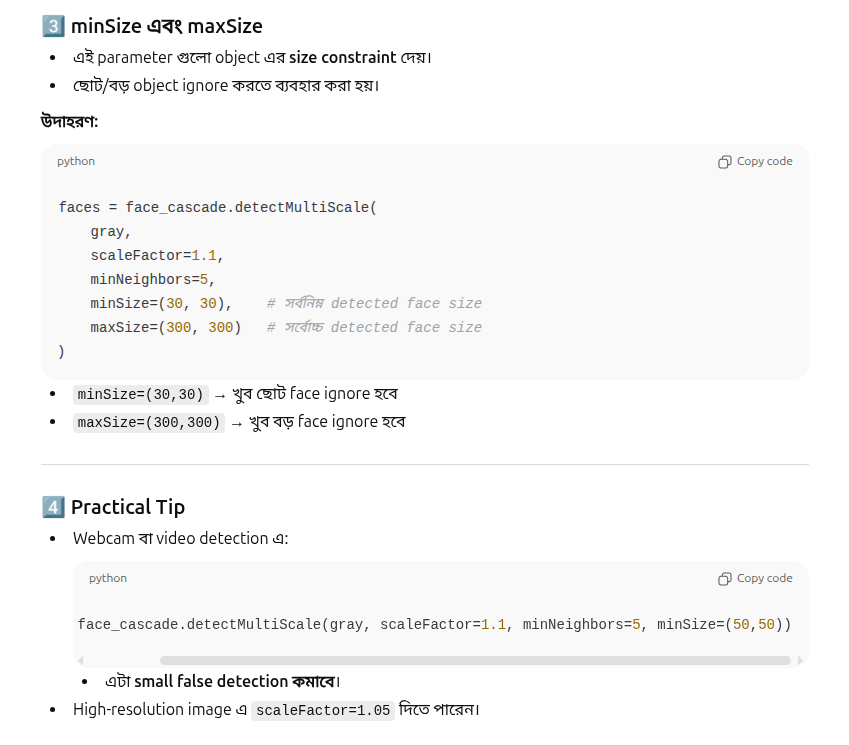

## 1. Individual Image Detection¶

In [6]:
import cv2

# 1️⃣ Haar Cascade লোড করা
face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')

# 2️⃣ ইমেজ লোড করা
img_path = "../dataset/test/bellingham.jpg"   # 👉 আপনার ইমেজ পাথ দিন
img = cv2.imread(img_path)

# 3️⃣ ইমেজকে গ্রেস্কেলে রূপান্তর
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# 4️⃣ মুখ সনাক্তকরণ (parameter সহ)
faces = face_cascade.detectMultiScale(
    gray,
    scaleFactor=1.1,      # detection sensitivity (1.05–1.2 এর মধ্যে ভাল কাজ করে)
    minNeighbors=5,        # false detection কমানোর জন্য ৫–৬ ভালো মান
    minSize=(50, 50),      # ছোট মুখ বাদ দেবে
    maxSize=(300, 300)     # বড় মুখ বাদ দেবে
)

# 5️⃣ সনাক্ত মুখের চারপাশে rectangle আঁকা
for (x, y, w, h) in faces:
    cv2.rectangle(img, (x, y), (x+w, y+h), (255, 0, 0), 2)

# 6️⃣ ফলাফল দেখানো
cv2.imshow('Haar Cascade - Face Detection (Image)', img)
cv2.waitKey(0)
cv2.destroyAllWindows()

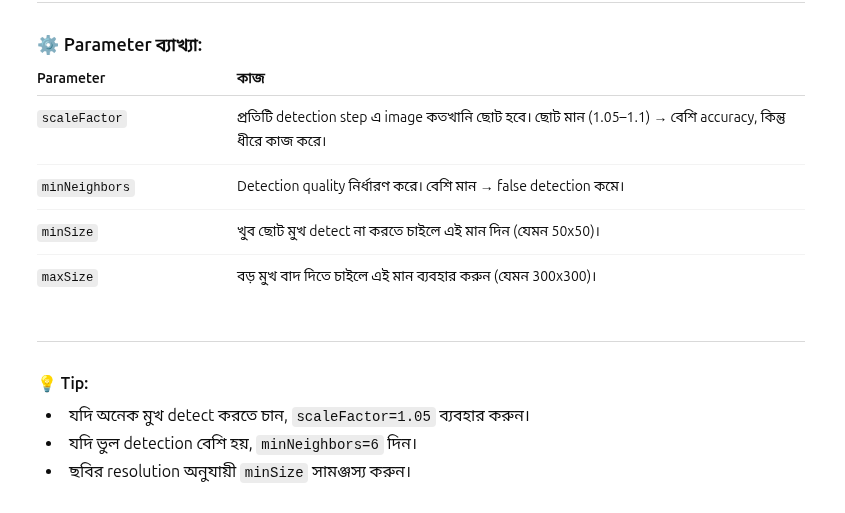

## 2. Face Detection (Video File)

In [7]:
import cv2

# 1️⃣ Haar Cascade লোড করা
face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')

# 2️⃣ ভিডিও ফাইল লোড করা
video_path = "../dataset/vid/s.mp4"  # 👉 আপনার ভিডিও ফাইলের path দিন
cap = cv2.VideoCapture(video_path)

# 3️⃣ ভিডিও ফ্রেম ধরে ধরে পড়া
while True:
    ret, frame = cap.read()
    if not ret:
        break  # ভিডিও শেষ হলে বেরিয়ে আসবে

    # 4️⃣ প্রতিটি ফ্রেমকে grayscale এ রূপান্তর
    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

    # 5️⃣ মুখ সনাক্তকরণ
    faces = face_cascade.detectMultiScale(
        gray,
        scaleFactor=1.1,      # detection sensitivity
        minNeighbors=5,        # false detection কমাতে
        minSize=(50, 50),      # ছোট মুখ বাদ দিতে
        maxSize=(300, 300)     # বড় মুখ বাদ দিতে
    )

    # 6️⃣ সনাক্ত মুখের চারপাশে rectangle আঁকা
    for (x, y, w, h) in faces:
        cv2.rectangle(frame, (x, y), (x+w, y+h), (0, 255, 0), 2)

    # 7️⃣ ফ্রেম show করা
    cv2.imshow("Haar Cascade - Face Detection (Video)", frame)

    # 8️⃣ 'q' চাপলে ভিডিও বন্ধ হবে
    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

# 9️⃣ সব রিসোর্স রিলিজ করা
cap.release()
cv2.destroyAllWindows()

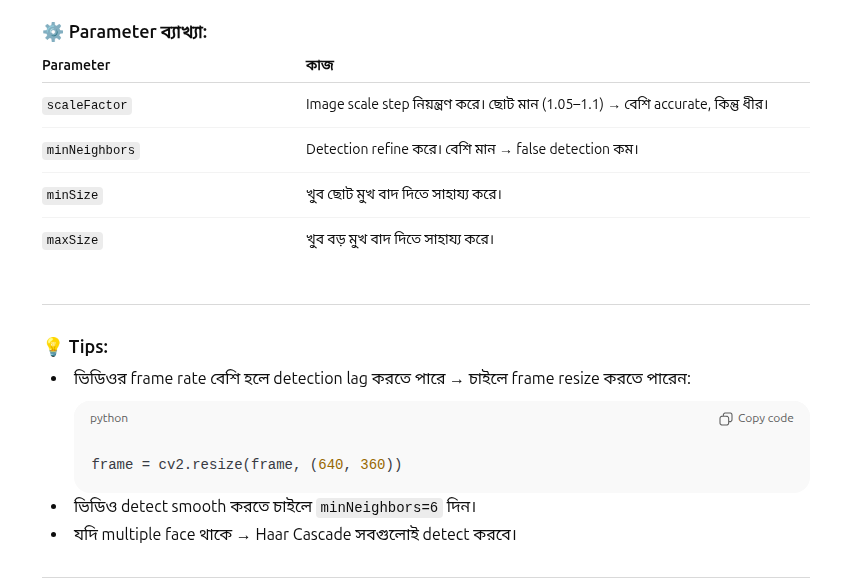

## 3. Webcam Real-Time Face Detection

In [5]:
import cv2

# 1️⃣ Haar Cascade লোড
face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')

# 2️⃣ Webcam Capture
cap = cv2.VideoCapture(0)  # 0 → default webcam

while True:
    ret, frame = cap.read()
    if not ret:
        break

    # 3️⃣ Grayscale conversion
    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

    # 4️⃣ Face Detection with parameters
    faces = face_cascade.detectMultiScale(
        gray,
        scaleFactor=1.1,      # detection sensitivity
        minNeighbors=5,        # quality control
        minSize=(50, 50),      # ignore very small faces
        maxSize=(300, 300)     # ignore very large faces
    )

    # 5️⃣ Draw rectangle around faces
    for (x, y, w, h) in faces:
        cv2.rectangle(frame, (x, y), (x+w, y+h), (0, 255, 0), 2)

    # 6️⃣ Show frame
    cv2.imshow('Webcam Face Detection', frame)

    # 7️⃣ Quit on 'q' key
    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

# 8️⃣ Release resources
cap.release()
cv2.destroyAllWindows()

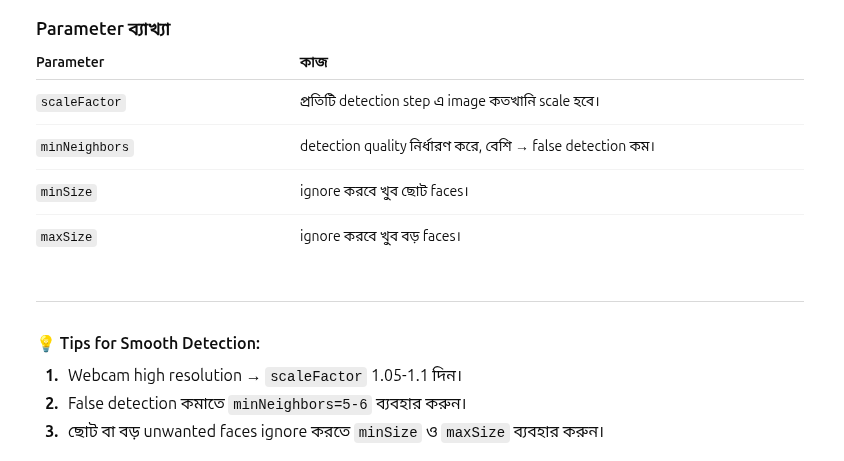